In [84]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rounakbanik/pokemon")

print("Path to dataset files:", path)

Path to dataset files: /home/alex/.cache/kagglehub/datasets/rounakbanik/pokemon/versions/1


In [85]:

path1 = kagglehub.dataset_download("maca11/all-pokemon-dataset")

print("Path to dataset files:", path1)


Path to dataset files: /home/alex/.cache/kagglehub/datasets/maca11/all-pokemon-dataset/versions/7


In [86]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [87]:
import os
os.listdir(path)

['pokemon.csv']

In [88]:
os.listdir(path1)

['All_Pokemon.csv']

In [89]:
bk = df = pd.read_csv(os.path.join(path,'pokemon.csv'))

In [90]:
bk1 = df1 = pd.read_csv(os.path.join(path1,'All_Pokemon.csv'))

In [91]:
df1.columns #all pokemon dataset

Index(['Number', 'Name', 'Type 1', 'Type 2', 'Abilities', 'HP', 'Att', 'Def',
       'Spa', 'Spd', 'Spe', 'BST', 'Mean', 'Standard Deviation', 'Generation',
       'Experience type', 'Experience to level 100', 'Final Evolution',
       'Catch Rate', 'Legendary', 'Mega Evolution', 'Alolan Form',
       'Galarian Form', 'Against Normal', 'Against Fire', 'Against Water',
       'Against Electric', 'Against Grass', 'Against Ice', 'Against Fighting',
       'Against Poison', 'Against Ground', 'Against Flying', 'Against Psychic',
       'Against Bug', 'Against Rock', 'Against Ghost', 'Against Dragon',
       'Against Dark', 'Against Steel', 'Against Fairy', 'Height', 'Weight',
       'BMI'],
      dtype='object')

In [92]:
df.columns # old data set

Index(['abilities', 'against_bug', 'against_dark', 'against_dragon',
       'against_electric', 'against_fairy', 'against_fight', 'against_fire',
       'against_flying', 'against_ghost', 'against_grass', 'against_ground',
       'against_ice', 'against_normal', 'against_poison', 'against_psychic',
       'against_rock', 'against_steel', 'against_water', 'attack',
       'base_egg_steps', 'base_happiness', 'base_total', 'capture_rate',
       'classfication', 'defense', 'experience_growth', 'height_m', 'hp',
       'japanese_name', 'name', 'percentage_male', 'pokedex_number',
       'sp_attack', 'sp_defense', 'speed', 'type1', 'type2', 'weight_kg',
       'generation', 'is_legendary'],
      dtype='object')

new data set df1 implementation

In [93]:
df1.columns = df1.columns.str.strip()

df_new = df1.rename(columns={
    "Number": "pokedex_number",
    "Name": "name",
    "Type 1": "type1",
    "Type 2": "type2",
    "HP": "hp",
    "Att": "attack",
    "Def": "defense",
    "Spa": "sp_attack",
    "Spd": "sp_defense",
    "Spe": "speed",
    "Legendary": "is_legendary",
    "Height": "height_m",
    "Weight": "weight_kg",
    "Catch Rate": "capture_rate"
})

In [94]:
df_new.columns = (
    df_new.columns
    .str.replace("Against ", "against_", regex=False)
    .str.lower()
    .str.replace(" ", "_")
)

In [95]:
df_new["type2"] = df_new["type2"].fillna("none")

In [96]:
df_new = df_new.rename(columns={
    "bst": "base_total"
})

In [97]:
bk = df_new.copy()
df = df_new.copy()

In [98]:
df.head()

,pokedex_number,name,type1,type2,abilities,hp,attack,defense,sp_attack,sp_defense,...,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy,height_m,weight_kg,bmi
0,1,Bulbasaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",45,49,49,65,65,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,0.7,6.9,14.1
1,2,Ivysaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",60,62,63,80,80,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,1.0,13.0,13.0
2,3,Venusaur,Grass,Poison,"['Chlorophyll', 'Overgrow']",80,82,83,100,100,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,2.0,100.0,25.0
3,3,Mega Venusaur,Grass,Poison,['Thick Fat'],80,100,123,122,120,...,1.0,1.0,1.0,1.0,1.0,1.0,0.5,2.4,155.5,27.0
4,4,Charmander,Fire,none,"['Blaze', 'Solar Power']",39,52,43,60,50,...,0.5,2.0,1.0,1.0,1.0,0.5,0.5,0.6,8.5,23.6


In [99]:
cor = df.corr(numeric_only=True)
cor

,pokedex_number,hp,attack,defense,sp_attack,sp_defense,speed,base_total,mean,standard_deviation,...,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy,height_m,weight_kg,bmi
pokedex_number,1.000000,0.108518,0.123581,0.093584,0.092315,0.076661,0.024718,0.129655,0.129655,0.025323,...,-0.001180,-0.036093,0.087863,0.025943,0.039492,0.066956,0.153700,0.042423,0.122692,0.042095
hp,0.108518,1.000000,0.448109,0.270759,0.367900,0.364979,0.182416,0.636355,0.636355,0.319102,...,0.027286,-0.051314,-0.042344,0.131821,0.009546,0.028108,0.141482,0.443746,0.440130,-0.032756
attack,0.123581,0.448109,1.000000,0.462794,0.368953,0.272079,0.375853,0.742052,0.742052,0.338257,...,-0.059827,-0.118487,-0.006141,0.127855,-0.097930,0.010166,0.206421,0.425432,0.427314,-0.049515
defense,0.093584,0.270759,0.462794,1.000000,0.220302,0.528080,-0.005132,0.619106,0.619106,0.449801,...,-0.057604,-0.167991,0.142700,-0.038324,0.058447,0.048914,-0.014090,0.362805,0.469828,0.059071
sp_attack,0.092315,0.367900,0.368953,0.220302,1.000000,0.514828,0.443517,0.736265,0.736265,0.203043,...,0.073850,0.065894,0.269777,0.092446,0.213719,-0.062613,0.024121,0.383695,0.238078,-0.044129
sp_defense,0.076661,0.364979,0.272079,0.528080,0.514828,1.000000,0.219159,0.711452,0.711452,0.345154,...,0.015744,-0.011937,0.210760,-0.040481,0.148679,0.079080,0.018332,0.322137,0.303296,0.065807
speed,0.024718,0.182416,0.375853,-0.005132,0.443517,0.219159,1.000000,0.560673,0.560673,0.049156,...,-0.020782,0.125646,0.015344,0.118629,0.017516,-0.079070,0.116826,0.197547,0.052252,-0.035814
base_total,0.129655,0.636355,0.742052,0.619106,0.736265,0.711452,0.560673,1.000000,1.000000,0.422135,...,-0.006508,-0.039485,0.151059,0.098818,0.087097,0.002667,0.122764,0.531366,0.478253,-0.011221
mean,0.129655,0.636355,0.742052,0.619106,0.736265,0.711452,0.560673,1.000000,1.000000,0.422135,...,-0.006508,-0.039485,0.151059,0.098818,0.087097,0.002667,0.122764,0.531366,0.478253,-0.011221
standard_deviation,0.025323,0.319102,0.338257,0.449801,0.203043,0.345154,0.049156,0.422135,0.422135,1.000000,...,-0.051731,-0.102292,0.124427,-0.068970,0.083296,0.109908,0.005951,0.303494,0.347870,0.075462


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1032 entries, 0 to 1031
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   pokedex_number           1032 non-null   int64  
 1   name                     1032 non-null   object 
 2   type1                    1032 non-null   object 
 3   type2                    1032 non-null   object 
 4   abilities                1032 non-null   object 
 5   hp                       1032 non-null   int64  
 6   attack                   1032 non-null   int64  
 7   defense                  1032 non-null   int64  
 8   sp_attack                1032 non-null   int64  
 9   sp_defense               1032 non-null   int64  
 10  speed                    1032 non-null   int64  
 11  base_total               1032 non-null   int64  
 12  mean                     1032 non-null   float64
 13  standard_deviation       1032 non-null   float64
 14  generation              

In [101]:
df.tail()

,pokedex_number,name,type1,type2,abilities,hp,attack,defense,sp_attack,sp_defense,...,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy,height_m,weight_kg,bmi
1027,896,Glastrier,Ice,none,['Chilling Neigh'],100,145,130,65,110,...,1.0,2.0,1.0,1.0,1.0,2.0,1.0,2.2,800.0,165.3
1028,897,Spectrier,Ghost,none,['Grim Neigh'],100,65,60,145,80,...,0.5,1.0,2.0,1.0,2.0,1.0,1.0,2.0,44.5,11.1
1029,898,Calyrex,Psychic,Grass,['Unnerve'],100,80,80,80,80,...,4.0,1.0,2.0,1.0,2.0,1.0,1.0,1.1,7.7,6.4
1030,898,Calyrex Ice Rider,Psychic,Ice,['As One'],100,165,150,85,130,...,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.4,809.1,140.5
1031,898,Calyrex Shadow Rider,Psychic,Ghost,['As One'],100,85,80,165,100,...,1.0,1.0,4.0,1.0,4.0,1.0,1.0,2.4,53.6,9.3


In [102]:
df.duplicated().sum()

0

In [103]:
df.columns

Index(['pokedex_number', 'name', 'type1', 'type2', 'abilities', 'hp', 'attack',
       'defense', 'sp_attack', 'sp_defense', 'speed', 'base_total', 'mean',
       'standard_deviation', 'generation', 'experience_type',
       'experience_to_level_100', 'final_evolution', 'capture_rate',
       'is_legendary', 'mega_evolution', 'alolan_form', 'galarian_form',
       'against_normal', 'against_fire', 'against_water', 'against_electric',
       'against_grass', 'against_ice', 'against_fighting', 'against_poison',
       'against_ground', 'against_flying', 'against_psychic', 'against_bug',
       'against_rock', 'against_ghost', 'against_dragon', 'against_dark',
       'against_steel', 'against_fairy', 'height_m', 'weight_kg', 'bmi'],
      dtype='object')

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Grass'),
  Text(1, 0, 'Fire'),
  Text(2, 0, 'Water'),
  Text(3, 0, 'Bug'),
  Text(4, 0, 'Normal'),
  Text(5, 0, 'Dark'),
  Text(6, 0, 'Poison'),
  Text(7, 0, 'Electric'),
  Text(8, 0, 'Ground'),
  Text(9, 0, 'Ice'),
  Text(10, 0, 'Fairy'),
  Text(11, 0, 'Steel'),
  Text(12, 0, 'Fighting'),
  Text(13, 0, 'Psychic'),
  Text(14, 0, 'Rock'),
  Text(15, 0, 'Ghost'),
  Text(16, 0, 'Dragon'),
  Text(17, 0, 'Flying')])

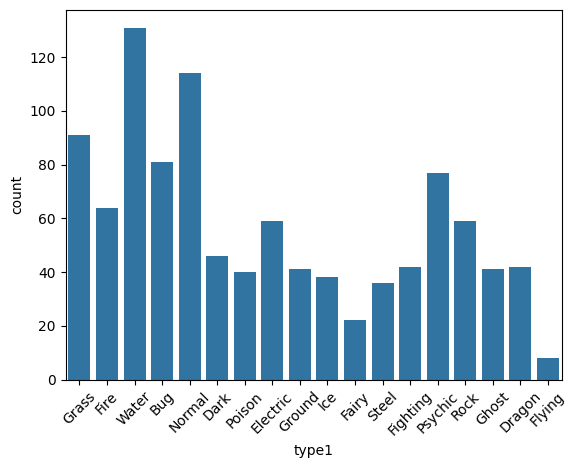

In [104]:
sns.countplot(x=df['type1'])
plt.xticks(rotation=45)
# plt.show()

array([[<Axes: title={'center': 'hp'}>,
        <Axes: title={'center': 'attack'}>],
       [<Axes: title={'center': 'defense'}>,
        <Axes: title={'center': 'sp_attack'}>],
       [<Axes: title={'center': 'sp_defense'}>,
        <Axes: title={'center': 'speed'}>]], dtype=object)

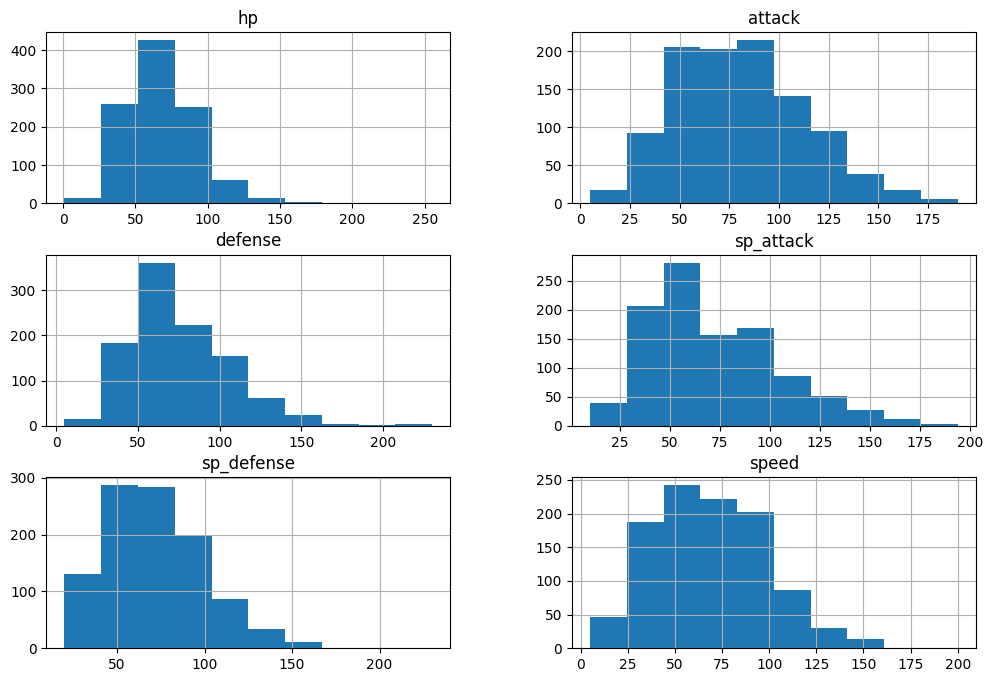

In [105]:
stats = ['hp','attack','defense','sp_attack','sp_defense','speed']

df[stats].hist(figsize=(12,8))
# plt.show()

<Axes: >

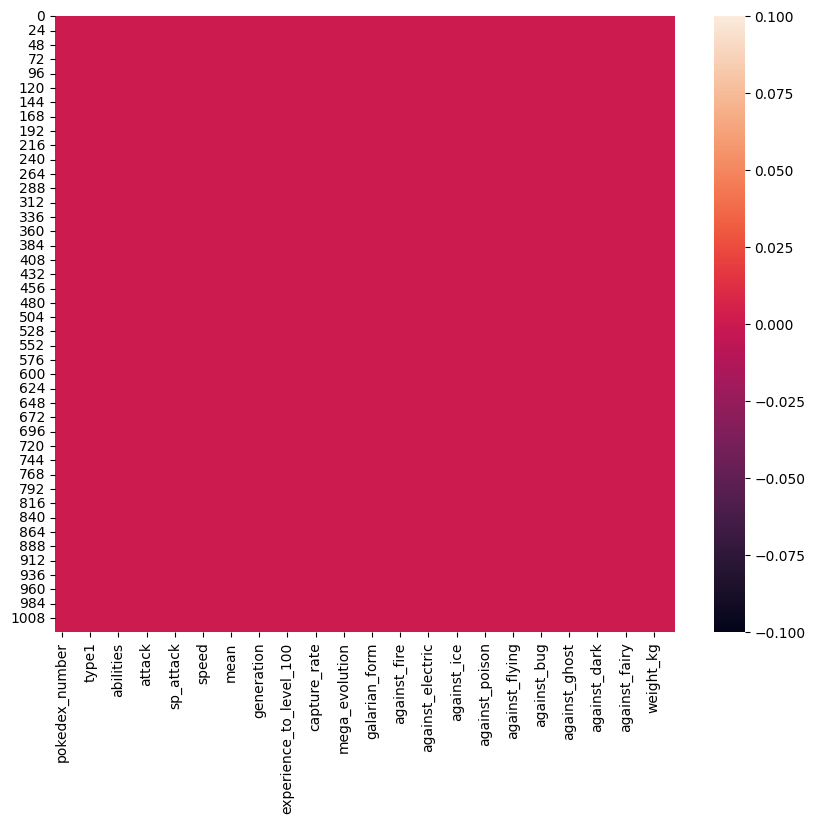

In [106]:
plt.figure(figsize=(10,8))
sns.heatmap(df.isna())
# plt.show()

<Axes: >

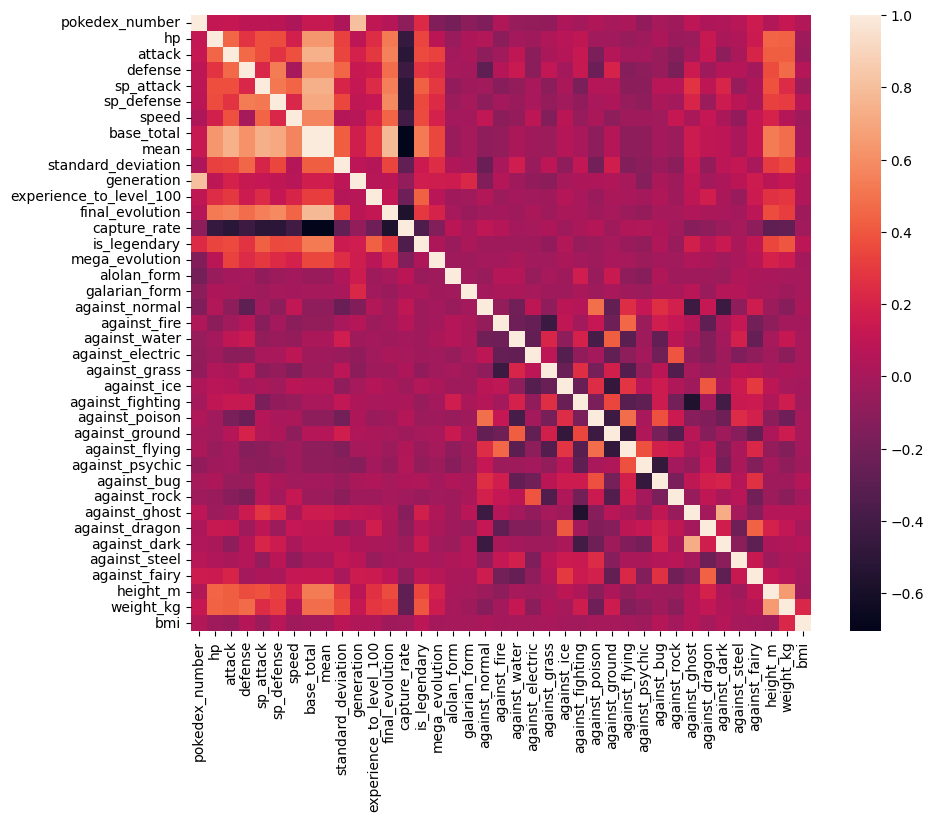

In [107]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True))
# plt.show()

<Axes: xlabel='type1'>

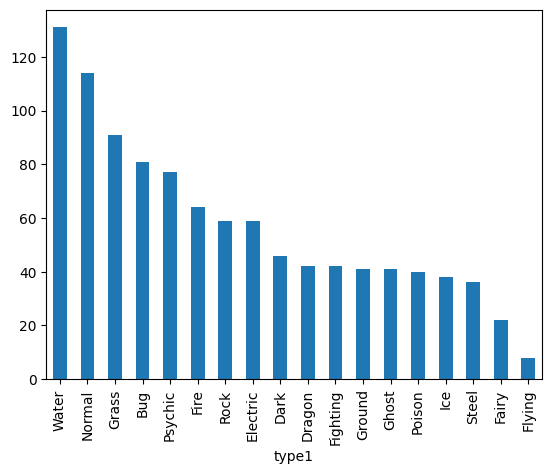

In [108]:
df['type1'].value_counts().plot(kind='bar')
# plt.show()

In [109]:
df["physical_power"] = df["attack"] + df["defense"]
df["special_power"] = df["sp_attack"] + df["sp_defense"]
df["total_combat"] = df["physical_power"] + df["special_power"] + df["speed"]

In [110]:
df["speed_ratio"] = df["speed"] / df["base_total"]

In [111]:
df["bulk"] = df["hp"] + df["defense"] + df["sp_defense"]

In [112]:
type_cols = [col for col in df.columns if "against_" in col]

df["avg_type_resistance"] = df[type_cols].mean(axis=1)
df["max_weakness"] = df[type_cols].max(axis=1)

In [113]:
# cleaning
#

In [114]:
drop_cols = [
    "japanese_name",
    "name",
    "pokedex_number",
    "classfication",
    "abilities"
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])


# Why?
# 
# Text-heavy
# 
# High cardinality
# 
# Not useful for battle modeling

In [115]:
df.describe(include='all')

,type1,type2,hp,attack,defense,sp_attack,sp_defense,speed,base_total,mean,...,height_m,weight_kg,bmi,physical_power,special_power,total_combat,speed_ratio,bulk,avg_type_resistance,max_weakness
count,1032,1032,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,...,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000,1032.000000
unique,18,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Water,none,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,131,484,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,69.906008,80.526163,74.609496,72.918605,72.139535,68.548450,438.648256,73.108043,...,1.286822,71.879845,136.735756,155.135659,145.058140,368.742248,0.157872,216.655039,1.058247,2.401163
std,NaN,NaN,26.189155,32.542374,30.905972,32.773495,27.625876,30.219526,120.675545,20.112591,...,1.391501,132.872741,3111.666658,54.268766,52.626408,105.953751,0.059302,65.363768,0.109119,0.801259
min,NaN,NaN,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000,29.166667,...,0.100000,0.100000,0.000000,10.000000,35.000000,120.000000,0.009901,70.000000,0.736111,2.000000
25%,NaN,NaN,50.000000,55.000000,50.000000,50.000000,50.000000,45.000000,330.000000,55.000000,...,0.600000,9.000000,18.600000,115.000000,105.000000,275.000000,0.116667,166.000000,1.000000,2.000000
50%,NaN,NaN,67.000000,78.000000,70.000000,65.000000,70.000000,65.000000,459.000000,76.500000,...,1.000000,29.750000,28.350000,150.500000,140.000000,380.000000,0.153775,215.000000,1.041667,2.000000
75%,NaN,NaN,83.000000,100.000000,90.000000,95.000000,90.000000,90.000000,515.000000,85.833333,...,1.600000,71.275000,42.200000,190.000000,180.000000,435.000000,0.198707,263.250000,1.125000,2.000000


In [116]:
df.isna().sum().sort_values(ascending=False)

type1                      0
type2                      0
against_fighting           0
against_poison             0
against_ground             0
against_flying             0
against_psychic            0
against_bug                0
against_rock               0
against_ghost              0
against_dragon             0
against_dark               0
against_steel              0
against_fairy              0
height_m                   0
weight_kg                  0
bmi                        0
physical_power             0
special_power              0
total_combat               0
speed_ratio                0
bulk                       0
avg_type_resistance        0
against_ice                0
against_grass              0
against_electric           0
generation                 0
hp                         0
attack                     0
defense                    0
sp_attack                  0
sp_defense                 0
speed                      0
base_total                 0
mean          

In [117]:
df["type2"] = df["type2"].fillna("None")

In [118]:
df["height_m"] = df["height_m"].fillna(df["height_m"].median())
df["weight_kg"] = df["weight_kg"].fillna(df["weight_kg"].median())

In [120]:
df = df.drop(columns=['percentage_male'], errors='ignore')

In [121]:
df["capture_rate"] = pd.to_numeric(df["capture_rate"], errors="coerce")
df["capture_rate"] = df["capture_rate"].fillna(df["capture_rate"].median())

In [122]:
df.duplicated().sum()
df = df.drop_duplicates()

<Axes: >

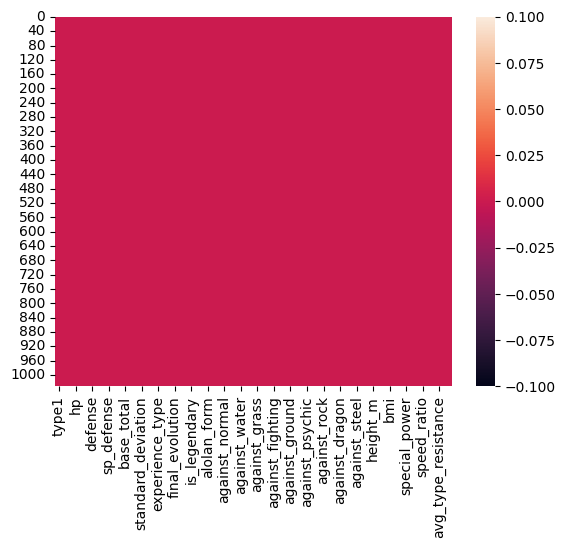

In [123]:
sns.heatmap(df.isna())


# Handle Outliers

In [124]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = df[col].clip(lower, upper)


# encoding

In [125]:
df = pd.get_dummies(df, columns=["type1","type2","generation"], drop_first=True)

In [126]:
df["is_legendary"] = df["is_legendary"].astype(int)

In [140]:
df = df.select_dtypes(include=["int64", "float64", "bool"])

In [141]:
X = df.drop("is_legendary", axis=1)
y = df["is_legendary"]

In [142]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=["int64","float64"]).columns

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [144]:
# Simulation

In [145]:
# Damage = (Attack / Defense) * Power * TypeMultiplier

In [146]:
def simulate_battle(p1, p2):

    # Base damage
    p1_damage = (p1["attack"] / p2["defense"]) * p1["speed"]
    p2_damage = (p2["attack"] / p1["defense"]) * p2["speed"]

    # Get types from backup dataset
    p1_types = [str(bk.loc[p1.name, "type1"]).lower(), str(bk.loc[p1.name, "type2"]).lower()]
    p2_types = [str(bk.loc[p2.name, "type1"]).lower(), str(bk.loc[p2.name, "type2"]).lower()]

    type_mapping = {"fighting": "fight"}

    # Compute multipliers (Corrected: Attacker's types against Defender's resistance)
    p1_multiplier = 1
    for t in p1_types:
        if t != "nan":
            col = f"against_{type_mapping.get(t, t)}"
            p1_multiplier = max(p1_multiplier, p2.get(col, 1))

    p2_multiplier = 1
    for t in p2_types:
        if t != "nan":
            col = f"against_{type_mapping.get(t, t)}"
            p2_multiplier = max(p2_multiplier, p1.get(col, 1))

    # Apply multiplier
    p1_damage *= p1_multiplier
    p2_damage *= p2_multiplier

    # Add randomness
    p1_damage *= np.random.uniform(0.85, 1.2)
    p2_damage *= np.random.uniform(0.85, 1.2)

    # Final score
    p1_score = p1_damage + (p1["hp"] + p1["sp_defense"])
    p2_score = p2_damage + (p2["hp"] + p2["sp_defense"])

    if p1_score > p2_score:
        return 1
    else:
        return 0

In [147]:
def generate_battles(df, n_battles=50000):

    battles = []

    for _ in range(n_battles):

        p1 = df.sample(1).iloc[0]
        p2 = df.sample(1).iloc[0]

        winner = simulate_battle(p1, p2)

        battle_features = {}

        for col in df.columns:
            if col != "is_legendary":
                battle_features[f"p1_{col}"] = p1[col]
                battle_features[f"p2_{col}"] = p2[col]

        battle_features["winner"] = winner

        battles.append(battle_features)

    return pd.DataFrame(battles)

In [148]:
battle_df = generate_battles(df, n_battles=50000)

In [149]:
battle_df.head()

,p1_hp,p2_hp,p1_attack,p2_attack,p1_defense,p2_defense,p1_sp_attack,p2_sp_attack,p1_sp_defense,p2_sp_defense,...,p2_generation_4.0,p1_generation_5.0,p2_generation_5.0,p1_generation_6.0,p2_generation_6.0,p1_generation_7.0,p2_generation_7.0,p1_generation_8.0,p2_generation_8.0,winner
0,50.0,68.0,35.0,105.0,55.0,70.0,25.0,70.0,25.0,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
1,75.0,123.0,100.0,77.0,95.0,72.0,40.0,99.0,70.0,92.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1
2,65.0,105.0,63.0,95.0,45.0,80.0,45.0,40.0,45.0,80.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,100.0,100.0,130.0,125.0,100.0,90.0,63.0,60.0,60.0,70.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0
4,35.0,75.0,60.0,125.0,44.0,75.0,40.0,30.0,54.0,75.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [150]:
X = battle_df.drop("winner", axis=1)
y = battle_df["winner"]

In [154]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [155]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [159]:
preds = model.predict(X_test)

In [160]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, preds))
print(classification_report(y_test, preds))

[[4633  354]
 [ 344 4669]]
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      4987
           1       0.93      0.93      0.93      5013

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



In [161]:
def predict_battle(pokemon1_name, pokemon2_name):
    
    # 1️⃣ Find index using backup dataset
    idx1 = bk[bk["name"] == pokemon1_name].index[0]
    idx2 = bk[bk["name"] == pokemon2_name].index[0]
    
    # 2️⃣ Get processed rows from training dataset
    p1 = df.loc[idx1]
    p2 = df.loc[idx2]
    
    # 3️⃣ Build battle feature dictionary
    battle_features = {}
    
    for col in df.columns:
        battle_features[f"p1_{col}"] = p1[col]
        battle_features[f"p2_{col}"] = p2[col]
    
    # 4️⃣ Convert to dataframe
    battle_df_test = pd.DataFrame([battle_features])
    
    # 5️⃣ Align columns exactly like training data
    model_columns = battle_df.drop("winner", axis=1).columns
    battle_df_test = battle_df_test.reindex(columns=model_columns, fill_value=0)
    
    # 6️⃣ Predict
    prediction = model.predict(battle_df_test)[0]
    
    if prediction == 1:
        print(f"{pokemon1_name} wins!")
    else:
        print(f"{pokemon2_name} wins!")

In [162]:
def battle(pokemon1_name, pokemon2_name):

    # Find index
    idx1 = bk[bk["name"] == pokemon1_name].index[0]
    idx2 = bk[bk["name"] == pokemon2_name].index[0]

    p1 = df.loc[idx1]
    p2 = df.loc[idx2]

    # Build feature row
    battle_features = {}

    for col in df.columns:
        battle_features[f"p1_{col}"] = p1[col]
        battle_features[f"p2_{col}"] = p2[col]

    battle_df_test = pd.DataFrame([battle_features])

    model_columns = battle_df.drop("winner", axis=1).columns
    battle_df_test = battle_df_test.reindex(columns=model_columns, fill_value=0)

    # 🔥 1️⃣ ML Prediction
    proba = model.predict_proba(battle_df_test)[0]
    p1_win_prob = proba[1]
    p2_win_prob = proba[0]

    print("=== AI Prediction ===")
    print(f"{pokemon1_name} win probability: {p1_win_prob:.2f}")
    print(f"{pokemon2_name} win probability: {p2_win_prob:.2f}")

    # 🔥 2️⃣ Live Simulation
    sim_result, battle_log = simulate_turn_battle(p1, p2)

    print("\n=== Live Battle Log ===")
    for entry in battle_log:
        print(entry)

    print("\n=== Result ===")
    if sim_result == 1:
        print(f"{pokemon1_name} wins! ⚔️")
    else:
        print(f"{pokemon2_name} wins! ⚔️")

In [163]:
def simulate_turn_battle(p1, p2):

    # Copy HP so original data not modified
    p1_hp = p1["hp"]
    p2_hp = p2["hp"]

    log = []

    # Map fighting for consistency in dataset naming
    type_mapping = {"fighting": "fight"}

    # Determine turn order
    if p1["speed"] >= p2["speed"]:
        first, second = p1, p2
        first_name, second_name = "P1", "P2"
    else:
        first, second = p2, p1
        first_name, second_name = "P2", "P1"

    round_num = 1

    while p1_hp > 0 and p2_hp > 0:

        log.append(f"\n-- Round {round_num} --")

        # First attacks
        if np.random.rand() < 0.5:
            damage = (first["attack"] / second["defense"]) * 10
            log.append(f"{first_name} uses Physical attack!")
        else:
            damage = (first["sp_attack"] / second["sp_defense"]) * 10
            log.append(f"{first_name} uses Special attack!")

        # Correct type multiplier logic
        first_types = [str(bk.loc[first.name, "type1"]).lower(), str(bk.loc[first.name, "type2"]).lower()]
        second_types = [str(bk.loc[second.name, "type1"]).lower(), str(bk.loc[second.name, "type2"]).lower()]
        
        multiplier = 1
        for t in first_types:
            if t != "nan":
                col = f"against_{type_mapping.get(t, t)}"
                multiplier = max(multiplier, second.get(col, 1))
        
        damage *= multiplier
        if multiplier > 1: log.append("It's super effective! ✨")
        if multiplier < 1 and multiplier != 0: log.append("It's not very effective... 🍃")
        if multiplier == 0: log.append("It had no effect! 😶")

        damage *= np.random.uniform(0.85, 1.0)

        # critical hit
        if np.random.rand() < 0.06:
            damage *= 1.5
            log.append("💥 Critical hit!")

        if first_name == "P1":
            p2_hp -= damage
            log.append(f"P1 deals {damage:.2f} damage.")
        else:
            p1_hp -= damage
            log.append(f"P2 deals {damage:.2f} damage.")

        if p1_hp <= 0 or p2_hp <= 0:
            break

        # Second attacks (Corrected second attacker index)
        if np.random.rand() < 0.5:
            damage = (second["attack"] / first["defense"]) * 10
            log.append(f"{second_name} uses Physical attack!")
        else:
            damage = (second["sp_attack"] / first["sp_defense"]) * 10
            log.append(f"{second_name} uses Special attack!")

        # Correct type multiplier logic
        multiplier = 1
        for t in second_types:
            if t != "nan":
                col = f"against_{type_mapping.get(t, t)}"
                multiplier = max(multiplier, first.get(col, 1))

        damage *= multiplier
        if multiplier > 1: log.append("It's super effective! ✨")
        if multiplier < 1 and multiplier != 0: log.append("It's not very effective... 🍃")
        if multiplier == 0: log.append("It had no effect! 😶")

        damage *= np.random.uniform(0.85, 1.0)

        # critical hit
        if np.random.rand() < 0.06:
            damage *= 1.5
            log.append("💥 Critical hit!")

        if first_name == "P1":
            p1_hp -= damage
            log.append(f"P2 deals {damage:.2f} damage.")
        else:
            p2_hp -= damage
            log.append(f"P1 deals {damage:.2f} damage.")

        round_num += 1

        log.append(f"P1 HP: {max(p1_hp,0):.2f}")
        log.append(f"P2 HP: {max(p2_hp,0):.2f}")

    winner = 1 if p1_hp > 0 else 0

    return winner, log

In [164]:
battle("Pikachu", "Charizard")

=== AI Prediction ===
Pikachu win probability: 0.00
Charizard win probability: 1.00

=== Live Battle Log ===

-- Round 1 --
P2 uses Physical attack!
P2 deals 20.50 damage.
P1 uses Special attack!
It's super effective! ✨
P1 deals 9.24 damage.
P1 HP: 14.50
P2 HP: 68.76

-- Round 2 --
P2 uses Physical attack!
P2 deals 19.79 damage.

=== Result ===
Charizard wins! ⚔️


In [165]:
battle("Blastoise", "Charizard")

=== AI Prediction ===
Blastoise win probability: 0.58
Charizard win probability: 0.42

=== Live Battle Log ===

-- Round 1 --
P2 uses Special attack!
P2 deals 9.41 damage.
P1 uses Special attack!
It's super effective! ✨
P1 deals 14.97 damage.
P1 HP: 69.59
P2 HP: 63.03

-- Round 2 --
P2 uses Physical attack!
P2 deals 7.21 damage.
P1 uses Special attack!
It's super effective! ✨
P1 deals 16.22 damage.
P1 HP: 62.38
P2 HP: 46.80

-- Round 3 --
P2 uses Special attack!
P2 deals 9.03 damage.
P1 uses Special attack!
It's super effective! ✨
P1 deals 15.45 damage.
P1 HP: 53.35
P2 HP: 31.36

-- Round 4 --
P2 uses Special attack!
P2 deals 9.09 damage.
P1 uses Special attack!
It's super effective! ✨
P1 deals 16.98 damage.
P1 HP: 44.26
P2 HP: 14.37

-- Round 5 --
P2 uses Physical attack!
P2 deals 7.88 damage.
P1 uses Physical attack!
It's super effective! ✨
P1 deals 18.49 damage.
P1 HP: 36.38
P2 HP: 0.00

=== Result ===
Blastoise wins! ⚔️


In [171]:
battle("Glastrier", "Mewtwo")

=== AI Prediction ===
Glastrier win probability: 0.20
Mewtwo win probability: 0.80

=== Live Battle Log ===

-- Round 1 --
P2 uses Physical attack!
P2 deals 8.07 damage.
P1 uses Physical attack!
P1 deals 15.55 damage.
P1 HP: 91.93
P2 HP: 90.45

-- Round 2 --
P2 uses Special attack!
💥 Critical hit!
P2 deals 18.68 damage.
P1 uses Physical attack!
P1 deals 15.97 damage.
P1 HP: 73.24
P2 HP: 74.48

-- Round 3 --
P2 uses Special attack!
P2 deals 12.43 damage.
P1 uses Physical attack!
P1 deals 15.16 damage.
P1 HP: 60.81
P2 HP: 59.32

-- Round 4 --
P2 uses Special attack!
P2 deals 13.77 damage.
P1 uses Special attack!
P1 deals 6.41 damage.
P1 HP: 47.05
P2 HP: 52.91

-- Round 5 --
P2 uses Physical attack!
P2 deals 7.28 damage.
P1 uses Physical attack!
P1 deals 15.96 damage.
P1 HP: 39.77
P2 HP: 36.95

-- Round 6 --
P2 uses Physical attack!
P2 deals 8.00 damage.
P1 uses Special attack!
P1 deals 7.02 damage.
P1 HP: 31.77
P2 HP: 29.92

-- Round 7 --
P2 uses Special attack!
P2 deals 12.67 damage.
P1

/home/alex/ml-env/tf-gpu/bin/python app.py

In [170]:
bk.tail()

,pokedex_number,name,type1,type2,abilities,hp,attack,defense,sp_attack,sp_defense,...,against_bug,against_rock,against_ghost,against_dragon,against_dark,against_steel,against_fairy,height_m,weight_kg,bmi
1027,896,Glastrier,Ice,none,['Chilling Neigh'],100,145,130,65,110,...,1.0,2.0,1.0,1.0,1.0,2.0,1.0,2.2,800.0,165.3
1028,897,Spectrier,Ghost,none,['Grim Neigh'],100,65,60,145,80,...,0.5,1.0,2.0,1.0,2.0,1.0,1.0,2.0,44.5,11.1
1029,898,Calyrex,Psychic,Grass,['Unnerve'],100,80,80,80,80,...,4.0,1.0,2.0,1.0,2.0,1.0,1.0,1.1,7.7,6.4
1030,898,Calyrex Ice Rider,Psychic,Ice,['As One'],100,165,150,85,130,...,2.0,2.0,2.0,1.0,2.0,2.0,1.0,2.4,809.1,140.5
1031,898,Calyrex Shadow Rider,Psychic,Ghost,['As One'],100,85,80,165,100,...,1.0,1.0,4.0,1.0,4.0,1.0,1.0,2.4,53.6,9.3
